# DQN Training and Evaluation Notebook

This notebook contains the Gymnasium-compatible environment, fixed-friction DQN evaluation, drag-sensitive DQN evaluation, and final multi-seed comparison.

In [2]:
# %pip install numpy matplotlib scipy gymnasium stable-baselines3 torch
# If the above command doesnt work or if the required packages are missing in the JupyterHub environment 
# then run the command below:

%pip install --upgrade --force-reinstall \
  "numpy==1.26.4" \
  "scipy==1.14.0" \
  "torch==2.3.1" \
  "torchvision==0.18.1" \
  "torchaudio==2.3.1" \
  "gymnasium==1.2.3" \
  "stable-baselines3==2.7.1" \
  "matplotlib==3.9.1"

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.14.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached torch-2.3.1-cp311-cp311-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.18.1-cp311-cp311-manylinux1_x86_64.whl.metadata (6.6 kB)
  Using cached torchaudio-2.3.1-cp311-cp311-manylinux1_x86_64.whl.metadata (6.4 kB)
  Using cached gymnasium-1.2.3-py3-none-any.whl.metadata (10 kB)
  Using cached stable_baselines3-2.7.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached matplotlib-3.9.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-p

In [3]:
# Import core libraries used throughout the DQN notebook.
# NumPy and Matplotlib are used for numerical work and plotting.
# Gymnasium provides the RL environment interface.
# Stable-Baselines3 provides the DQN implementation, monitoring, callbacks and evaluation utilities.
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

import torch

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv

In [4]:
# Set random seeds for reproducibility.
# This helps make DQN training and evaluation more consistent across runs.
# The hardware check prints whether CUDA/GPU acceleration is available.
SEED = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.3.1+cu121
CUDA available: True
GPU: NVIDIA A40


In [5]:
# Core racing-fuel simulator.
# This class implements the underlying environment dynamics used by both optimisation and DQN experiments.
# It tracks the current round, remaining fuel, and energy, then applies the fuel-burn, reward and carry-over rules.
# The same class supports both fixed-friction and drag-sensitive carry-over modes.
class RacingFuelEnv:
    """
    Deterministic racing fuel environment.

    State:
        t      = current round
        fuel   = remaining fuel
        energy = current kinetic-energy-like quantity

    Action:
        burn   = litres burned this round

    Reward:
        distance_t = sqrt(energy_after_burn)

    Extension:
        carry-over can be constant or energy-dependent.
    """

    def __init__(
        self,
        horizon=10,
        init_fuel=100.0,
        energy_per_litre=1.0,
        friction=0.90,
        max_burn=30.0,
        retention_mode="constant",          # "constant" or "energy_dependent"
        drag_base_retention=0.95,
        drag_coeff=0.0035,
        drag_min_retention=0.55,
        drag_max_retention=0.95,
        seed=None
    ):
        self.horizon = int(horizon)
        self.init_fuel = float(init_fuel)
        self.energy_per_litre = float(energy_per_litre)
        self.friction = float(friction)
        self.max_burn = float(max_burn)

        self.retention_mode = retention_mode
        self.drag_base_retention = float(drag_base_retention)
        self.drag_coeff = float(drag_coeff)
        self.drag_min_retention = float(drag_min_retention)
        self.drag_max_retention = float(drag_max_retention)

        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.reset()

    def _obs(self):
        return np.array([self.t, self.fuel, self.energy], dtype=np.float32)

    def _retention_from_energy(self, energy_after):
        if self.retention_mode == "constant":
            return self.friction

        rho = self.drag_base_retention - self.drag_coeff * energy_after
        return float(np.clip(rho, self.drag_min_retention, self.drag_max_retention))

    def reset(self):
        self.t = 0
        self.fuel = float(self.init_fuel)
        self.energy = 0.0
        return self._obs()

    # Clip the burn amount so the action never exceeds the remaining fuel or per-round burn limit.
    def step(self, burn):
        if self.t >= self.horizon:
            raise RuntimeError("Episode already finished. Call reset().")

        # Compute post-burn energy, reward/distance, retained energy, and updated fuel state.
        burn = float(np.clip(burn, 0.0, min(self.max_burn, self.fuel)))

        # Compute post-burn energy, reward/distance, retained energy, and updated fuel state.
        energy_after = self.energy + self.energy_per_litre * burn
        reward = float(np.sqrt(max(energy_after, 0.0)))

        # In fixed-friction mode, the carry-over coefficient is constant.
        # In drag-sensitive mode, retention decreases as post-burn energy increases.
        retention = self._retention_from_energy(energy_after)
        energy_next = retention * energy_after

        self.energy = energy_next
        self.fuel -= burn
        self.t += 1

        done = (self.t >= self.horizon)

        info = {
            "burn": burn,
            "speed": reward,
            "distance": reward,
            "energy_after": energy_after,
            "energy_next": energy_next,
            "retention": retention,
            "fuel": self.fuel,
            "t": self.t
        }

        return self._obs(), reward, done, info

In [6]:
# Gymnasium wrapper for the racing-fuel simulator.
# Stable-Baselines3 expects environments to follow the Gymnasium API.
# This wrapper converts the simulator into an RL environment with a discrete action space suitable for DQN.
class RacingFuelDiscreteGymEnv(gym.Env):

    metadata = {"render_modes": []}

    def __init__(
        self,
        horizon=10,
        init_fuel=100.0,
        energy_per_litre=1.0,
        friction=0.90,
        max_burn=30.0,
        action_step_litres=1.0,
        normalize_obs=True,
        retention_mode="constant",
        drag_base_retention=0.95,
        drag_coeff=0.0035,
        drag_min_retention=0.55,
        drag_max_retention=0.95,
        energy_scale=150.0,
        seed=None
    ):
        super().__init__()

        self.horizon = int(horizon)
        self.init_fuel = float(init_fuel)
        self.energy_per_litre = float(energy_per_litre)
        self.friction = float(friction)
        self.max_burn = float(max_burn)
        self.action_step_litres = float(action_step_litres)
        self.normalize_obs = bool(normalize_obs)

        self.retention_mode = retention_mode
        self.drag_base_retention = float(drag_base_retention)
        self.drag_coeff = float(drag_coeff)
        self.drag_min_retention = float(drag_min_retention)
        self.drag_max_retention = float(drag_max_retention)

        self.energy_scale = float(energy_scale)
        self.seed_value = seed

        self.base_env = RacingFuelEnv(
            horizon=self.horizon,
            init_fuel=self.init_fuel,
            energy_per_litre=self.energy_per_litre,
            friction=self.friction,
            max_burn=self.max_burn,
            retention_mode=self.retention_mode,
            drag_base_retention=self.drag_base_retention,
            drag_coeff=self.drag_coeff,
            drag_min_retention=self.drag_min_retention,
            drag_max_retention=self.drag_max_retention,
            seed=seed
        )

        # DQN requires discrete actions.
        # With one-litre action steps from 0 to 30 litres, the agent has 31 possible actions.
        self.n_actions = int(round(self.max_burn / self.action_step_litres)) + 1
        self.action_space = spaces.Discrete(self.n_actions)

        if self.normalize_obs:
            low = np.array([0.0, 0.0, 0.0], dtype=np.float32)
            high = np.array([1.0, 1.0, 1.0], dtype=np.float32)
        else:
            low = np.array([0.0, 0.0, 0.0], dtype=np.float32)
            high = np.array([self.horizon, self.init_fuel, self.energy_scale], dtype=np.float32)

        self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

    # Normalise observations so that round, fuel and energy are on similar numeric scales.
    # This helps DQN training stability.
    def _normalize_obs(self, obs):
        t, fuel, energy = obs.astype(np.float32)

        if not self.normalize_obs:
            return np.array([t, fuel, energy], dtype=np.float32)

        t_norm = t / max(1.0, self.horizon)
        fuel_norm = fuel / max(1.0, self.init_fuel)
        energy_norm = min(energy, self.energy_scale) / max(1.0, self.energy_scale)

        return np.array([t_norm, fuel_norm, energy_norm], dtype=np.float32)

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.seed_value = seed

        self.base_env = RacingFuelEnv(
            horizon=self.horizon,
            init_fuel=self.init_fuel,
            energy_per_litre=self.energy_per_litre,
            friction=self.friction,
            max_burn=self.max_burn,
            retention_mode=self.retention_mode,
            drag_base_retention=self.drag_base_retention,
            drag_coeff=self.drag_coeff,
            drag_min_retention=self.drag_min_retention,
            drag_max_retention=self.drag_max_retention,
            seed=self.seed_value
        )

        obs = self.base_env.reset()
        info = {
            "action_step_litres": self.action_step_litres,
            "energy_scale": self.energy_scale,
            "horizon": self.horizon,
            "init_fuel": self.init_fuel,
            "max_burn": self.max_burn,
            "normalize_obs": self.normalize_obs,
            "seed": self.seed_value
        }
        return self._normalize_obs(obs), info

    # Convert the discrete action index into an actual fuel-burn value in litres.
    # Then pass that burn value into the base simulator.
    def step(self, action):
        burn = float(action) * self.action_step_litres
        obs, reward, done, info = self.base_env.step(burn)

        terminated = done
        truncated = False

        return self._normalize_obs(obs), reward, terminated, truncated, info

In [7]:
# Smoke test for the Gymnasium environment.
# This verifies that reset() and step() work correctly, and that the observation/action spaces have the expected format.
# The output confirms that the environment can be used by Stable-Baselines3.
env = RacingFuelDiscreteGymEnv(
    horizon=10,
    init_fuel=100.0,
    friction=0.90,
    max_burn=30.0,
    action_step_litres=1.0,
    normalize_obs=True,
    seed=SEED
)

obs, info = env.reset()
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Reset obs:", obs)
print("Reset info:", info)

action = 10
obs, reward, terminated, truncated, info = env.step(action)
print("Step obs:", obs)
print("Reward:", reward)
print("Terminated:", terminated, "Truncated:", truncated)
print("Info:", info)

Observation space: Box(0.0, 1.0, (3,), float32)
Action space: Discrete(31)
Reset obs: [0. 1. 0.]
Reset info: {'action_step_litres': 1.0, 'energy_scale': 150.0, 'horizon': 10, 'init_fuel': 100.0, 'max_burn': 30.0, 'normalize_obs': True, 'seed': 0}
Step obs: [0.1  0.9  0.06]
Reward: 3.1622776601683795
Terminated: False Truncated: False
Info: {'burn': 10.0, 'speed': 3.1622776601683795, 'distance': 3.1622776601683795, 'energy_after': 10.0, 'energy_next': 9.0, 'retention': 0.9, 'fuel': 90.0, 't': 1}


In [8]:
# Main environment configuration for the drag-sensitive DQN experiment.
# The race uses 10 rounds, 100 litres of fuel, and a maximum burn of 30 litres per round.
# retention_mode="energy_dependent" enables the drag-sensitive carry-over model.
env_kwargs = dict(
    horizon=10,
    init_fuel=100.0,
    energy_per_litre=1.0,
    friction=0.90,                  # only used if retention_mode="constant"
    max_burn=30.0,
    action_step_litres=1.0,
    normalize_obs=True,

    # Drag-sensitive carry-over settings
    retention_mode="energy_dependent",
    drag_base_retention=0.95,
    drag_coeff=0.0035,
    drag_min_retention=0.55,
    drag_max_retention=0.95,
    energy_scale=150.0,

    seed=SEED
)

In [9]:
# Factory function used by Stable-Baselines3.
# It creates a fresh monitored environment for a given random seed.
# Monitor records episode returns during training/evaluation.
def make_env(seed, normalize_obs=True):
    def _init():
        local_kwargs = dict(env_kwargs)
        local_kwargs["seed"] = seed
        local_kwargs["normalize_obs"] = normalize_obs

        env = RacingFuelDiscreteGymEnv(**local_kwargs)
        env = Monitor(env)
        return env
    return _init

In [10]:
# Create separate vectorised training and evaluation environments.
# The evaluation environment uses a different seed so that evaluation is separated from training setup.
# DummyVecEnv is required because Stable-Baselines3 expects vectorised environments.
train_env = DummyVecEnv([make_env(SEED, normalize_obs=True)])
eval_env = DummyVecEnv([make_env(SEED + 100, normalize_obs=True)])

In [11]:
# Define where drag-sensitive DQN logs and the best model checkpoint will be saved.
# The best_model folder is used by EvalCallback to store the strongest policy found during training.
LOG_DIR = "./rf_drag_dqn"
BEST_DIR = os.path.join(LOG_DIR, "best_model")

os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(BEST_DIR, exist_ok=True)

print("Saving logs to:", LOG_DIR)
print("Saving best model to:", BEST_DIR)

Saving logs to: ./rf_drag_dqn
Saving best model to: ./rf_drag_dqn/best_model


In [12]:
# Evaluation callback used during DQN training.
# Every eval_freq steps, the current policy is evaluated deterministically.
# If it performs better than previous checkpoints, it is saved as best_model.zip.
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=BEST_DIR,
    log_path=LOG_DIR,
    eval_freq=2000,
    n_eval_episodes=100,
    deterministic=True,
    render=False,
    verbose=1
)

In [13]:
# Define the DQN model and its hyperparameters.
# A small MLP policy is sufficient because the observation space is low-dimensional:
# round number, remaining fuel, and current energy.
# gamma=1.0 is used because the objective is total undiscounted distance over a short finite horizon.
model = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    buffer_size=20000,
    learning_starts=500,
    batch_size=64,
    gamma=1.0,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=250,
    exploration_fraction=0.6,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[64, 64]),
    verbose=1,
    seed=SEED,
    device="auto"
)

Using cuda device


In [40]:
# Train the drag-sensitive DQN model.
# This is a long-running cell because it performs reinforcement-learning training.
# It does not need to be rerun unless retraining the agent from scratch.
TOTAL_TIMESTEPS = 150_000

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback,
    progress_bar=True
)

print("Training complete.")

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 60.8     |
|    exploration_rate | 1        |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2724     |
|    time_elapsed     | 0        |
|    total_timesteps  | 40       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 59.5     |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3432     |
|    time_elapsed     | 0        |
|    total_timesteps  | 80       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 60       |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes       

Eval num_timesteps=2000, episode_reward=61.23 +/- 0.00

Episode length: 10.00 +/- 0.00

----------------------------------
| eval/               |          |
|    mean_ep_length   | 10       |
|    mean_reward      | 61.2     |
| rollout/            |          |
|    exploration_rate | 0.979    |
| time/               |          |
|    total_timesteps  | 2000     |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 3.39     |
|    n_updates        | 1499     |
----------------------------------


New best mean reward!

...

----------------------------------
| eval/               |          |
|    mean_ep_length   | 10       |
|    mean_reward      | 62.6     |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 148000   |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.000254 |
|    n_updates        | 147499   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 62.7     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 14800    |
|    fps              | 280      |
|    time_elapsed     | 527      |
|    total_timesteps  | 148000   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 62.7     |
|    exploration_rat

Eval num_timesteps=150000, episode_reward=62.81 +/- 0.00

Episode length: 10.00 +/- 0.00

----------------------------------
| eval/               |          |
|    mean_ep_length   | 10       |
|    mean_reward      | 62.8     |
| rollout/            |          |
|    exploration_rate | 0.05     |
| time/               |          |
|    total_timesteps  | 150000   |
| train/              |          |
|    learning_rate    | 0.0003   |
|    loss             | 0.000389 |
|    n_updates        | 149499   |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 10       |
|    ep_rew_mean      | 62.7     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 15000    |
|    fps              | 280      |
|    time_elapsed     | 535      |
|    total_timesteps  | 150000   |
----------------------------------


Training complete.


In [14]:
# Load the best drag-sensitive DQN checkpoint saved by EvalCallback.
# This is kept separate from the fixed-friction best model to avoid variable confusion.

drag_best_model_path = os.path.join(BEST_DIR, "best_model.zip")
print("Drag-sensitive best model path:", drag_best_model_path)

drag_best_model = DQN.load(drag_best_model_path, env=eval_env)
print("Drag-sensitive best model loaded successfully.")

Drag-sensitive best model path: ./rf_drag_dqn/best_model/best_model.zip
Drag-sensitive best model loaded successfully.


In [15]:
# Evaluate the best saved drag-sensitive DQN checkpoint using deterministic evaluation.
# This is the single-seed drag-sensitive DQN result reported before the multi-seed comparison.

drag_mean_return, drag_std_return = evaluate_policy(
    drag_best_model,
    eval_env,
    n_eval_episodes=200,
    deterministic=True
)

print(f"Best drag-sensitive model mean return: {drag_mean_return:.6f}")
print(f"Best drag-sensitive model std return:  {drag_std_return:.6f}")

Best drag-sensitive model mean return: 62.846642
Best drag-sensitive model std return:  0.000000


## Fixed-Friction DQN Evaluation

This section evaluates the saved fixed-friction DQN models and compares the final model against the best saved checkpoint.

In [16]:
# Re-import required libraries for the fixed-friction evaluation section.
# This makes the section easier to run independently if the notebook is restarted.
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

In [17]:
# Environment factory for the fixed-friction DQN evaluation.
# This uses the original constant-retention model with friction = 0.90.
def make_racingfuel_env(seed=0, normalize_obs=True):
    def _init():
        env = RacingFuelDiscreteGymEnv(
            horizon=10,
            init_fuel=100.0,
            energy_per_litre=1.0,
            friction=0.90,
            max_burn=30.0,
            action_step_litres=1.0,
            normalize_obs=normalize_obs,
            seed=seed
        )
        env = Monitor(env)
        return env
    return _init

In [18]:
# Create the fixed-friction evaluation environment.
# The observation space is printed to confirm that the model and environment are compatible.
eval_env = DummyVecEnv([make_racingfuel_env(seed=0, normalize_obs=True)])
print("Eval env obs space:", eval_env.observation_space)

Eval env obs space: Box(0.0, 1.0, (3,), float32)


In [19]:
# Load and evaluate the saved fixed-friction final model.
# This avoids accidentally evaluating the drag-sensitive model in the fixed-friction environment.

fixed_final_candidate_paths = [
    "./rf_dqn_logs/final_model.zip",
    "./rf_dqn_logs/final_model",
    "./rf_dqn_logs_fixed/final_model.zip",
    "./rf_dqn_logs_fixed/final_model",
    "./rf_clean_dqn/final_model.zip",
    "./rf_clean_dqn/final_model"
]


fixed_final_model_path = None

for p in fixed_final_candidate_paths:
    if os.path.exists(p):
        fixed_final_model_path = p
        break

if fixed_final_model_path is None:
    raise FileNotFoundError(
        "Could not find the saved fixed-friction final model. "
        "Expected one of: " + str(fixed_final_candidate_paths)
    )

fixed_final_model = DQN.load(fixed_final_model_path, env=eval_env)

fixed_final_mean, fixed_final_std = evaluate_policy(
    fixed_final_model,
    eval_env,
    n_eval_episodes=200,
    deterministic=True
)

print("Fixed-friction final model path:", fixed_final_model_path)
print(f"Fixed-friction final model return: {fixed_final_mean:.6f} ± {fixed_final_std:.6f}")

Fixed-friction final model path: ./rf_clean_dqn/final_model.zip
Fixed-friction final model return: 76.526545 ± 0.000000


In [20]:
# Locate and load the best fixed-friction DQN checkpoint.
# This is the checkpoint that matched the validated fixed-friction SLSQP optimum.

fixed_best_candidate_paths = [
    "./rf_dqn_logs/best_model/best_model.zip",
    "./rf_clean_dqn/best_model/best_model.zip",
    "./rf_dqn_logs_fixed/best_model/best_model.zip",
    "./rf_dqn_logs/best_model/best_model",
    "./rf_clean_dqn/best_model/best_model",
    "./rf_dqn_logs_fixed/best_model/best_model"
]

fixed_best_model_path = None

for p in fixed_best_candidate_paths:
    if os.path.exists(p):
        fixed_best_model_path = p
        break

if fixed_best_model_path is None:
    matches = glob.glob("./**/best_model.zip", recursive=True)
    if matches:
        fixed_best_model_path = matches[0]

if fixed_best_model_path is None:
    raise FileNotFoundError(
        "Could not find the saved fixed-friction best model. "
        "Expected one of: " + str(fixed_best_candidate_paths)
    )

fixed_best_model = DQN.load(fixed_best_model_path, env=eval_env)

fixed_best_mean, fixed_best_std = evaluate_policy(
    fixed_best_model,
    eval_env,
    n_eval_episodes=200,
    deterministic=True
)

print("Fixed-friction best model path:", fixed_best_model_path)
print(f"Fixed-friction best model return: {fixed_best_mean:.6f} ± {fixed_best_std:.6f}")

Fixed-friction best model path: ./rf_dqn_logs/best_model/best_model.zip
Fixed-friction best model return: 76.852839 ± 0.000000


In [21]:
# Compare fixed-friction DQN performance against the validated fixed-friction SLSQP optimum.
# The best checkpoint should match the optimiser to the reported precision.

FIXED_FRICTION_OPTIMUM = 76.852839

print(f"Fixed-friction SLSQP optimum: {FIXED_FRICTION_OPTIMUM:.6f}")
print(f"Fixed-friction final model:   {fixed_final_mean:.6f}")
print(f"Fixed-friction best model:    {fixed_best_mean:.6f}")
print(f"Best-model gap:               {FIXED_FRICTION_OPTIMUM - fixed_best_mean:.6f}")

Fixed-friction SLSQP optimum: 76.852839
Fixed-friction final model:   76.526545
Fixed-friction best model:    76.852839
Best-model gap:               0.000000


In [22]:
# Create a single non-vectorised fixed-friction environment for policy rollout.
# A normal Gymnasium environment is easier to inspect than a vectorised environment when extracting actions and burn schedules.
single_env = RacingFuelDiscreteGymEnv(
    horizon=10,
    init_fuel=100.0,
    energy_per_litre=1.0,
    friction=0.90,
    max_burn=30.0,
    action_step_litres=1.0,
    normalize_obs=True,
    seed=0
)

In [23]:
# Roll out a trained model for one complete episode.
# This records the chosen actions, burn schedule, rewards, remaining fuel, and energy trajectory.
# The rollout is used for policy-structure comparison, not just total return.
def rollout_single_env(env, mdl, seed=0):
    obs, info = env.reset(seed=seed)   # Gym API
    done = False

    burns = []
    rewards = []
    speeds = []
    fuels = []
    energies = []
    actions = []

    total = 0.0

    while not done:
        action, _ = mdl.predict(obs, deterministic=True)   # obs is numpy array
        obs, reward, terminated, truncated, info = env.step(action)

        actions.append(int(action))
        burns.append(float(info["burn"]))
        rewards.append(float(reward))
        speeds.append(float(info["speed"]))
        fuels.append(float(info["fuel"]))
        energies.append(float(env.base_env.energy))

        total += float(reward)
        done = terminated or truncated

    return {
        "total_return": total,
        "actions": np.array(actions),
        "burns": np.array(burns),
        "rewards": np.array(rewards),
        "speeds": np.array(speeds),
        "fuels": np.array(fuels),
        "energies": np.array(energies),
    }

In [24]:
# Extract deterministic rollouts for both the fixed-friction final model and best checkpoint.
# This allows the notebook to compare not only returns, but also the actual burn schedules.

final_roll = rollout_single_env(single_env, fixed_final_model, seed=0)
best_roll  = rollout_single_env(single_env, fixed_best_model, seed=0)

print("Final total return:", final_roll["total_return"])
print("Final burn schedule:", final_roll["burns"].tolist())

print("Best total return:", best_roll["total_return"])
print("Best burn schedule:", best_roll["burns"].tolist())

Final total return: 76.52654504644987
Final burn schedule: [30.0, 29.0, 20.0, 20.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Best total return: 76.85283893797144
Best burn schedule: [30.0, 30.0, 30.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


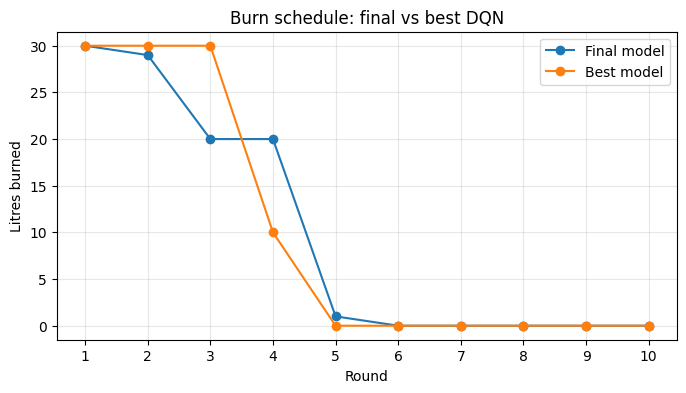

In [25]:
# Plot the fixed-friction burn schedules for the final model and best checkpoint.
# This shows why the best checkpoint is reported in the final evaluation.
rounds = np.arange(1, 11)

plt.figure(figsize=(8, 4))
plt.plot(rounds, final_roll["burns"], marker="o", label="Final model")
plt.plot(rounds, best_roll["burns"], marker="o", label="Best model")
plt.title("Burn schedule: final vs best DQN")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

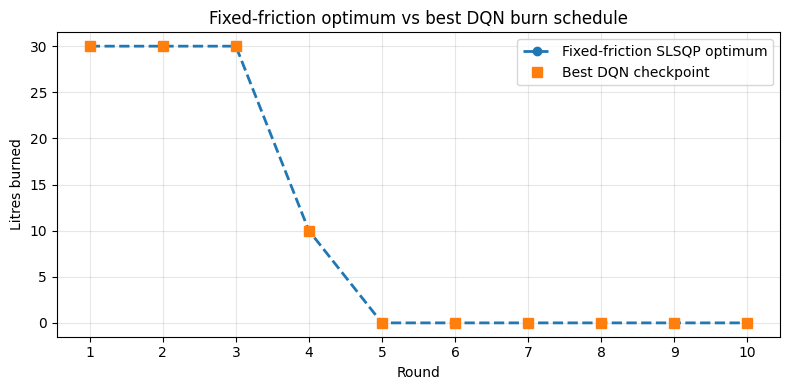

The schedules overlap exactly:
SLSQP optimum: [30.0, 30.0, 30.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Best DQN: [30.0, 30.0, 30.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [26]:
# Compare the validated fixed-friction SLSQP optimum against the best DQN checkpoint.
# The two schedules are identical, so the plot uses different markers/styles to make the overlap visible.

optimal_burns = np.array([30.0, 30.0, 30.0, 10.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

plt.figure(figsize=(8, 4))

plt.plot(
    rounds,
    optimal_burns,
    linestyle="--",
    marker="o",
    linewidth=2,
    label="Fixed-friction SLSQP optimum"
)

plt.plot(
    rounds,
    best_roll["burns"],
    linestyle="None",
    marker="s",
    markersize=7,
    label="Best DQN checkpoint"
)

plt.title("Fixed-friction optimum vs best DQN burn schedule")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("The schedules overlap exactly:")
print("SLSQP optimum:", optimal_burns.tolist())
print("Best DQN:", best_roll["burns"].tolist())

evaluations.npz found at: ./rf_clean_dqn/evaluations.npz


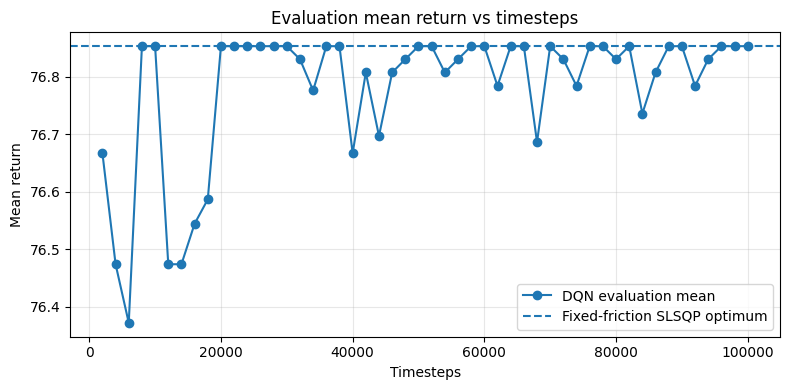

In [27]:
# Load saved evaluation logs from training, if available.
# The plot shows how the mean evaluation return changed over training timesteps.
# This provides evidence of convergence toward the fixed-friction optimum.

eval_npz = None

possible_eval_files = [
    "./rf_dqn_logs/evaluations.npz",
    "./rf_clean_dqn/evaluations.npz",
    "./rf_dqn_logs_fixed/evaluations.npz",
    "./rf_dqn_logs/eval/evaluations.npz",
    "./rf_clean_dqn/eval/evaluations.npz",
    "./rf_dqn_logs_fixed/eval/evaluations.npz",
]

for p in possible_eval_files:
    if os.path.exists(p):
        eval_npz = p
        break

if eval_npz is None:
    matches = glob.glob("./**/evaluations.npz", recursive=True)
    if matches:
        eval_npz = matches[0]

print("evaluations.npz found at:", eval_npz)

if eval_npz is not None:
    data = np.load(eval_npz)
    timesteps = data["timesteps"]
    results = data["results"]
    mean_returns = np.mean(results, axis=1)

    plt.figure(figsize=(8, 4))
    plt.plot(timesteps, mean_returns, marker="o", label="DQN evaluation mean")
    plt.axhline(
        FIXED_FRICTION_OPTIMUM,
        linestyle="--",
        label="Fixed-friction SLSQP optimum"
    )
    plt.title("Evaluation mean return vs timesteps")
    plt.xlabel("Timesteps")
    plt.ylabel("Mean return")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No evaluations.npz file found.")

## Drag-Sensitive DQN Evaluation

This section compares the drag-sensitive DQN policy against the rounded integer-feasible SLSQP benchmark.

In [40]:
# Drag-sensitive optimiser references from race_demo_drag.ipynb
# The continuous SLSQP optimum uses fractional litre values.
# The DQN uses one-litre actions, so DQN comparisons use the
# rounded integer-feasible benchmark.

drag_continuous_optimum_burns = np.array(
    [30.000, 20.883, 9.793, 9.793, 9.793, 9.793, 9.793, 0.152, 0.000, 0.000],
    dtype=float
)

drag_integer_benchmark_burns = np.array(
    [30, 21, 10, 9, 10, 10, 10, 0, 0, 0],
    dtype=float
)

DRAG_CONTINUOUS_OPTIMUM = 62.848043
DRAG_INTEGER_BENCHMARK = 62.847405

print("Continuous SLSQP optimum burns:", drag_continuous_optimum_burns.tolist())
print("Continuous SLSQP optimum return:", DRAG_CONTINUOUS_OPTIMUM)

print("\nRounded integer-feasible benchmark burns:", drag_integer_benchmark_burns.tolist())
print("Rounded integer-feasible benchmark return:", DRAG_INTEGER_BENCHMARK)

print("\nDQN uses one-litre discrete actions, so it is compared against the integer-feasible benchmark.")

Continuous SLSQP optimum burns: [30.0, 20.883, 9.793, 9.793, 9.793, 9.793, 9.793, 0.152, 0.0, 0.0]
Continuous SLSQP optimum return: 62.848043

Rounded integer-feasible benchmark burns: [30.0, 21.0, 10.0, 9.0, 10.0, 10.0, 10.0, 0.0, 0.0, 0.0]
Rounded integer-feasible benchmark return: 62.847405

DQN uses one-litre discrete actions, so it is compared against the integer-feasible benchmark.


In [42]:
# Compute simple baseline returns under the drag-sensitive model.
# These values are used in the report/video to show that neither greedy front-loading
# nor uniform fuel spreading is optimal under speed-dependent carry-over.

import numpy as np

def drag_retention(e_after, rho0=0.95, k=0.0035, rho_min=0.55, rho_max=0.95):
    """
    Speed-dependent carry-over coefficient.
    Higher post-burn energy gives lower retention, representing drag-sensitive losses.
    """
    return float(np.clip(rho0 - k * e_after, rho_min, rho_max))


def simulate_drag_schedule(burn_schedule):
    """
    Replay a fixed burn schedule through the drag-sensitive simulator.
    Returns total distance plus diagnostic trajectories.
    """
    energy = 0.0
    total_distance = 0.0

    energies_after_burn = []
    retention_values = []

    for burn in burn_schedule:
        e_after = energy + float(burn)
        reward = np.sqrt(max(e_after, 0.0))

        rho = drag_retention(e_after)
        energy = rho * e_after

        total_distance += reward
        energies_after_burn.append(e_after)
        retention_values.append(rho)

    return {
        "total_distance": float(total_distance),
        "burns": list(burn_schedule),
        "energies_after_burn": energies_after_burn,
        "retention_values": retention_values,
    }


# Greedy/front-loaded baseline: same shape as the fixed-friction optimum
greedy_drag_baseline = [30, 30, 30, 10, 0, 0, 0, 0, 0, 0]

# Uniform baseline: spreads 100 litres evenly across 10 rounds
uniform_drag_baseline = [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]

greedy_result = simulate_drag_schedule(greedy_drag_baseline)
uniform_result = simulate_drag_schedule(uniform_drag_baseline)

print("=== Drag-sensitive simple baselines ===")
print("Greedy burn schedule:", greedy_result["burns"])
print(f"Greedy total distance: {greedy_result['total_distance']:.6f}")

print("\nUniform burn schedule:", uniform_result["burns"])
print(f"Uniform total distance: {uniform_result['total_distance']:.6f}")

=== Drag-sensitive simple baselines ===
Greedy burn schedule: [30, 30, 30, 10, 0, 0, 0, 0, 0, 0]
Greedy total distance: 61.097609

Uniform burn schedule: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
Uniform total distance: 57.683472


In [43]:
# Roll out a DQN policy in the drag-sensitive environment.
# This records the burn schedule, rewards, energy-after-burn values, and retention coefficients.
# These quantities are used to compare the learned policy against the optimiser benchmark.
def rollout_single_env_drag(env, mdl, seed=0):
    obs, info = env.reset(seed=seed)
    done = False

    burns = []
    rewards = []
    speeds = []
    fuels = []
    energies = []
    retentions = []
    actions = []

    total = 0.0

    while not done:
        action, _ = mdl.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)

        actions.append(int(action))
        burns.append(float(info["burn"]))
        rewards.append(float(reward))
        speeds.append(float(info["speed"]))
        fuels.append(float(info["fuel"]))
        energies.append(float(info["energy_after"]))
        retentions.append(float(info["retention"]))

        total += float(reward)
        done = terminated or truncated

    return {
        "total_return": total,
        "actions": np.array(actions),
        "burns": np.array(burns),
        "rewards": np.array(rewards),
        "speeds": np.array(speeds),
        "fuels": np.array(fuels),
        "energies": np.array(energies),
        "retentions": np.array(retentions),
    }

In [44]:
# Create the drag-sensitive single environment and roll out the best DQN checkpoint.
# The printed return and burn schedule are compared against the integer-feasible optimiser benchmark.
drag_single_env = RacingFuelDiscreteGymEnv(**env_kwargs)

drag_roll = rollout_single_env_drag(drag_single_env, drag_best_model, seed=SEED)

print("DQN total return under drag-sensitive dynamics:", drag_roll["total_return"])
print("DQN burn schedule:", drag_roll["burns"].tolist())

DQN total return under drag-sensitive dynamics: 62.846641811892
DQN burn schedule: [30.0, 21.0, 10.0, 10.0, 10.0, 10.0, 9.0, 0.0, 0.0, 0.0]


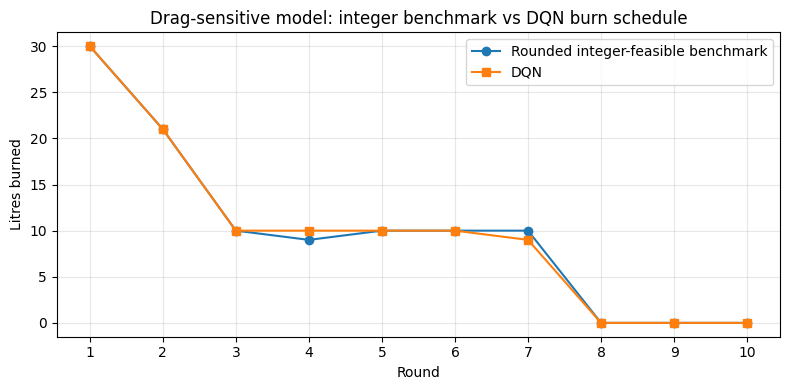

In [45]:
# Plot the drag-sensitive DQN burn schedule against the rounded integer-feasible optimiser benchmark.
# This is the main policy-structure comparison under the revised dynamics.
rounds = np.arange(1, len(drag_integer_benchmark_burns) + 1)

plt.figure(figsize=(8, 4))
plt.plot(
    rounds,
    drag_integer_benchmark_burns,
    marker="o",
    label="Rounded integer-feasible benchmark"
)
plt.plot(
    rounds,
    drag_roll["burns"],
    marker="s",
    label="DQN"
)
plt.title("Drag-sensitive model: integer benchmark vs DQN burn schedule")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("drag_dqn_vs_integer_benchmark_burns.png", dpi=300, bbox_inches="tight")
plt.show()

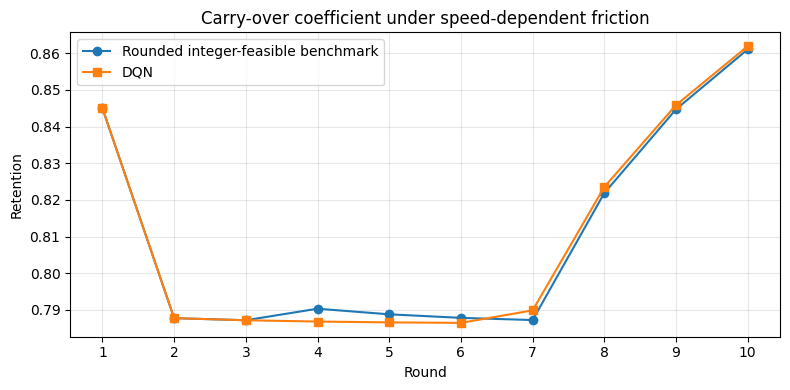

In [46]:
# Compute the benchmark retention path by replaying the rounded integer-feasible schedule
# Replay the integer-feasible optimiser benchmark through the drag-sensitive simulator.
# This extracts its retention path so it can be compared with the DQN retention path.
opt_env = RacingFuelEnv(
    horizon=env_kwargs["horizon"],
    init_fuel=env_kwargs["init_fuel"],
    energy_per_litre=env_kwargs["energy_per_litre"],
    friction=env_kwargs["friction"],
    max_burn=env_kwargs["max_burn"],
    retention_mode=env_kwargs["retention_mode"],
    drag_base_retention=env_kwargs["drag_base_retention"],
    drag_coeff=env_kwargs["drag_coeff"],
    drag_min_retention=env_kwargs["drag_min_retention"],
    drag_max_retention=env_kwargs["drag_max_retention"],
    seed=SEED
)

opt_env.reset()
opt_retentions = []
opt_energies = []

for b in drag_integer_benchmark_burns:
    _, _, done, info = opt_env.step(float(b))
    opt_retentions.append(info["retention"])
    opt_energies.append(info["energy_after"])
    if done:
        break

opt_retentions = np.array(opt_retentions)
opt_energies = np.array(opt_energies)

plt.figure(figsize=(8, 4))
plt.plot(
    rounds,
    opt_retentions,
    marker="o",
    label="Rounded integer-feasible benchmark"
)
plt.plot(
    rounds,
    drag_roll["retentions"],
    marker="s",
    label="DQN"
)
plt.title("Carry-over coefficient under speed-dependent friction")
plt.xlabel("Round")
plt.ylabel("Retention")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("drag_retention_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

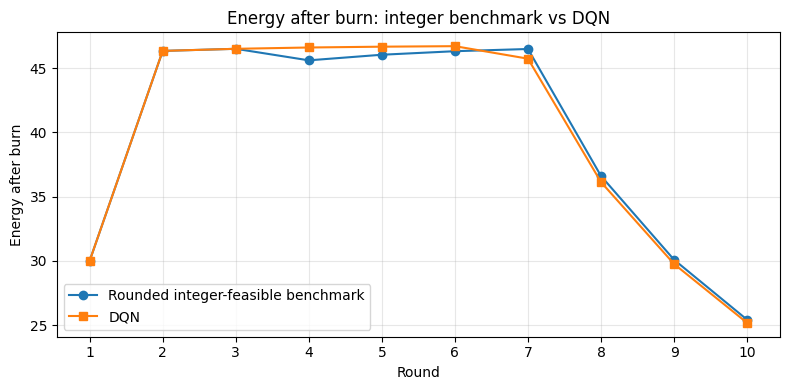

In [47]:
# Replay the integer-feasible optimiser benchmark through the drag-sensitive simulator.
# This extracts its retention path so it can be compared with the DQN retention path.
plt.figure(figsize=(8, 4))
plt.plot(
    rounds,
    opt_energies,
    marker="o",
    label="Rounded integer-feasible benchmark"
)
plt.plot(
    rounds,
    drag_roll["energies"],
    marker="s",
    label="DQN"
)
plt.title("Energy after burn: integer benchmark vs DQN")
plt.xlabel("Round")
plt.ylabel("Energy after burn")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("drag_energy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Multi-Seed Drag-Sensitive DQN Evaluation

This section reports the three-seed DQN evaluation and recreates the final DQN-versus-benchmark figure used in the report.

In [59]:
# Define final drag-sensitive benchmark values.
# The DQN gap is measured against the rounded integer-feasible benchmark because DQN uses whole-litre actions.
# The continuous optimum is kept as an upper reference only.
DRAG_INTEGER_BENCHMARK = 62.847405
DRAG_CONTINUOUS_OPTIMUM = 62.848043

print("Rounded integer-feasible benchmark:", DRAG_INTEGER_BENCHMARK)
print("Continuous SLSQP optimum:", DRAG_CONTINUOUS_OPTIMUM)
print("DQN gap should be measured against the integer-feasible benchmark.")

Rounded integer-feasible benchmark: 62.847405
Continuous SLSQP optimum: 62.848043
DQN gap should be measured against the integer-feasible benchmark.


In [60]:
# Define helper functions for the multi-seed drag-sensitive DQN experiment.
# Each seed trains a separate DQN agent, saves its best checkpoint, and evaluates that checkpoint deterministically.
# This cell defines the training function but does not start training by itself.
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.vec_env import DummyVecEnv
import os
import numpy as np

def make_env_with_kwargs(seed, env_kwargs_local):
    def _init():
        local_kwargs = dict(env_kwargs_local)
        local_kwargs["seed"] = seed
        env = RacingFuelDiscreteGymEnv(**local_kwargs)
        env = Monitor(env)
        return env
    return _init


def train_one_drag_dqn(
    seed,
    env_kwargs_local,
    total_timesteps=250_000,
    learning_rate=1e-4,
    buffer_size=50_000,
    learning_starts=1_000,
    batch_size=128,
    gamma=1.0,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=500,
    exploration_fraction=0.4,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.02,
    net_arch=[128, 128],
    root_log_dir="./rf_drag_multiseed"
):
    run_dir = os.path.join(root_log_dir, f"seed_{seed}")
    best_dir = os.path.join(run_dir, "best_model")
    os.makedirs(best_dir, exist_ok=True)

    train_env_local = DummyVecEnv([make_env_with_kwargs(seed, env_kwargs_local)])
    eval_env_local = DummyVecEnv([make_env_with_kwargs(seed + 1000, env_kwargs_local)])

    eval_callback_local = EvalCallback(
        eval_env_local,
        best_model_save_path=best_dir,
        log_path=run_dir,
        eval_freq=5000,
        n_eval_episodes=100,
        deterministic=True,
        render=False,
        verbose=0
    )

    model_local = DQN(
        policy="MlpPolicy",
        env=train_env_local,
        learning_rate=learning_rate,
        buffer_size=buffer_size,
        learning_starts=learning_starts,
        batch_size=batch_size,
        gamma=gamma,
        train_freq=train_freq,
        gradient_steps=gradient_steps,
        target_update_interval=target_update_interval,
        exploration_fraction=exploration_fraction,
        exploration_initial_eps=exploration_initial_eps,
        exploration_final_eps=exploration_final_eps,
        policy_kwargs=dict(net_arch=net_arch),
        verbose=0,
        seed=seed,
        device="auto"
    )

    # Train the DQN for this seed and save the best checkpoint through EvalCallback.
    model_local.learn(
        total_timesteps=total_timesteps,
        callback=eval_callback_local,
        progress_bar=True
    )

    best_path = os.path.join(best_dir, "best_model.zip")
    best_model_local = DQN.load(best_path, env=eval_env_local)

    mean_ret, std_ret = evaluate_policy(
        best_model_local,
        eval_env_local,
        n_eval_episodes=200,
        deterministic=True
    )

    # Return the key results needed for multi-seed comparison.
    return {
        "seed": seed,
        "run_dir": run_dir,
        "best_path": best_path,
        "mean_return": float(mean_ret),
        "std_return": float(std_ret),
        "gap_to_integer_benchmark": float(DRAG_INTEGER_BENCHMARK - mean_ret),
        "model": best_model_local
    }

In [62]:
# Full multi-seed training loop.
# This cell retrains three DQN agents and may take a long time to run.
# It is disabled by default because the completed multi-seed results are already reported below.

RUN_MULTI_SEED_TRAINING = False

if RUN_MULTI_SEED_TRAINING:
    results = []

    for s in [0, 1, 2]:
        print(f"\n===== Training seed {s} =====")
        res = train_one_drag_dqn(
            seed=s,
            env_kwargs_local=env_kwargs,
            total_timesteps=250_000
        )
        results.append(res)
        print(
            f"Seed {s} -> mean_return={res['mean_return']:.6f}, "
            f"gap_to_integer_benchmark={res['gap_to_integer_benchmark']:.6f}"
        )
else:
    print("Skipping multi-seed retraining. Using recorded completed-run values in the next cell.")

Skipping multi-seed retraining. Using recorded completed-run values in the next cell.


In [64]:
# Summarise the multi-seed DQN results.
# This cell uses the recorded completed-run values reported in the final report.
# It does not depend on the variable name "results", because that name may also be used by evaluation-log files.

seed_returns = np.array([62.846689, 62.844991, 62.844663], dtype=float)

best_seed = 0
best_return = float(np.max(seed_returns))
best_eval_std = 0.0
best_model_path = "./rf_drag_multiseed/seed_0/best_model/best_model.zip"

seed_mean = float(np.mean(seed_returns))
seed_std = float(np.std(seed_returns, ddof=1))  # sample standard deviation

print("=== Multi-seed DQN summary ===")
print("Seed returns:", [round(x, 6) for x in seed_returns.tolist()])
print(f"Mean return: {seed_mean:.6f}")
print(f"Sample standard deviation: {seed_std:.6f}")

print("\n=== Best DQN run ===")
print("Best seed:", best_seed)
print(f"Best return: {best_return:.6f}")
print(f"Best-run std from evaluate_policy: {best_eval_std:.6f}")
print(f"Gap to rounded integer-feasible benchmark: {DRAG_INTEGER_BENCHMARK - best_return:.6f}")
print("Best model path:", best_model_path)

if not os.path.exists(best_model_path):
    print("\nWARNING: Best model file was not found at this path.")
    print("This does not affect the reported summary values, but check the folder if you want to reload the model.")
else:
    print("\nBest model file found successfully.")

=== Multi-seed DQN summary ===
Seed returns: [62.846689, 62.844991, 62.844663]
Mean return: 62.845448
Sample standard deviation: 0.001087

=== Best DQN run ===
Best seed: 0
Best return: 62.846689
Best-run std from evaluate_policy: 0.000000
Gap to rounded integer-feasible benchmark: 0.000716
Best model path: ./rf_drag_multiseed/seed_0/best_model/best_model.zip

Best model file found successfully.


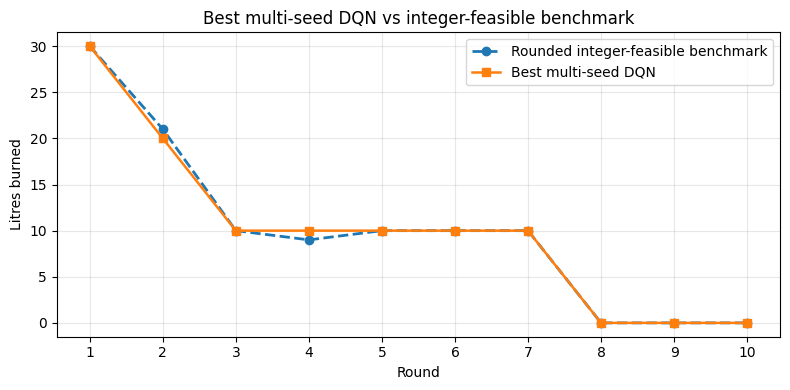

Saved figure:
 - drag_multiseed_dqn_vs_integer_benchmark.png
Best DQN return: 62.846689
Integer-feasible benchmark return: 62.847405
Gap: 0.000716
Benchmark burns: [30.0, 21.0, 10.0, 9.0, 10.0, 10.0, 10.0, 0.0, 0.0, 0.0]
Best DQN burns: [30.0, 20.0, 10.0, 10.0, 10.0, 10.0, 10.0, 0.0, 0.0, 0.0]


In [65]:
# Final report figure: best multi-seed DQN versus rounded integer-feasible benchmark.
# The schedules overlap across most rounds, so different line styles and markers are used for clarity.

import numpy as np
import matplotlib.pyplot as plt

rounds = np.arange(1, 11)

# Rounded integer-feasible SLSQP benchmark used for fair DQN comparison
drag_integer_benchmark_burns = np.array(
    [30, 21, 10, 9, 10, 10, 10, 0, 0, 0],
    dtype=float
)

# Best multi-seed DQN burn schedule from completed seed search
best_dqn_burns = np.array(
    [30, 20, 10, 10, 10, 10, 10, 0, 0, 0],
    dtype=float
)

plt.figure(figsize=(8, 4))

plt.plot(
    rounds,
    drag_integer_benchmark_burns,
    linestyle="--",
    marker="o",
    linewidth=2,
    label="Rounded integer-feasible benchmark"
)

plt.plot(
    rounds,
    best_dqn_burns,
    linestyle="-",
    marker="s",
    linewidth=1.8,
    label="Best multi-seed DQN"
)

plt.title("Best multi-seed DQN vs integer-feasible benchmark")
plt.xlabel("Round")
plt.ylabel("Litres burned")
plt.xticks(rounds)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("drag_multiseed_dqn_vs_integer_benchmark.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:")
print(" - drag_multiseed_dqn_vs_integer_benchmark.png")
print("Best DQN return: 62.846689")
print("Integer-feasible benchmark return: 62.847405")
print("Gap: 0.000716")
print("Benchmark burns:", drag_integer_benchmark_burns.tolist())
print("Best DQN burns:", best_dqn_burns.tolist())